# Parameter Sensitivity

This notebook uses the direct sensitivity solver in AutoReduce for a one-state decay model. Local sensitivity analysis is performed by solving the sensitivity equations alongside the original system, then comparing the result against an analytical expression.


## Model

The model is

$$
\dot{x} = -kx,
$$

with solution $x(t)=x_0e^{-kt}$. The sensitivity of the state with respect to $k$ is

$$
\frac{\partial x}{\partial k} = -t x_0 e^{-kt}.
$$


In [1]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sympy import Symbol

from autoreduce import System, solve_sensitivity

x = Symbol("x")
k = Symbol("k")

system = System(
    [x],
    [-k * x],
    params=[k],
    params_values=[0.4],
    x_init=[5.0],
    C=np.array([[1.0]]),
)


## Compute local sensitivities

`solve_sensitivity` returns an array indexed by time point, parameter, and state.


In [2]:
timepoints = np.linspace(0.0, 5.0, 1024)
sensitivities = solve_sensitivity(system, timepoints, normalize=False)

sensitivities.shape


(1024, 1, 1)

## Compare against analytical coefficients

For this model, the analytical expression is available, so it provides a compact check on the numerical sensitivity calculation.


In [3]:
x0 = system.x_init[0]
k_value = system.params_values[0]
analytical = -timepoints * x0 * np.exp(-k_value * timepoints)
numerical = sensitivities[:, 0, 0]

comparison = np.column_stack([timepoints, numerical, analytical])
comparison[:8]


array([[ 0.        ,  0.        , -0.        ],
       [ 0.00488759, -0.02439021, -0.0243902 ],
       [ 0.00977517, -0.04868514, -0.04868512],
       [ 0.01466276, -0.07288506, -0.07288505],
       [ 0.01955034, -0.09699027, -0.09699026],
       [ 0.02443793, -0.12100105, -0.12100103],
       [ 0.02932551, -0.14491766, -0.14491764],
       [ 0.0342131 , -0.16874038, -0.16874037]])

## Verify the sensitivity calculation

The maximum absolute error gives a direct numerical check of the computed sensitivity against the analytical expression.


In [4]:
absolute_error = np.abs(numerical - analytical)
max_absolute_error = float(np.max(absolute_error))
tolerance = 1e-6

assert max_absolute_error < tolerance
{
    "max_absolute_error": max_absolute_error,
    "tolerance": tolerance,
    "passes": max_absolute_error < tolerance,
}


{'max_absolute_error': 3.823501204536228e-08,
 'tolerance': 1e-06,
 'passes': True}

## Plot a sensitivity heatmap

The heatmap shows how the local sensitivity of $x$ to $k$ changes over time.


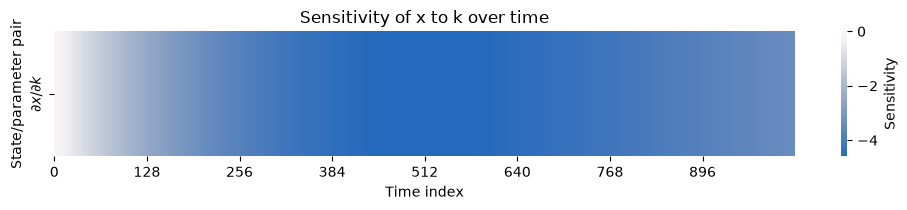

In [5]:
fig, ax = plt.subplots(figsize=(10, 2.2))
sns.heatmap(
    numerical.reshape(1, -1),
    cmap="vlag",
    center=0,
    xticklabels=128,
    yticklabels=[r"$\partial x / \partial k$"],
    cbar_kws={"label": "Sensitivity"},
    ax=ax,
)
ax.set_xlabel("Time index")
ax.set_ylabel("State/parameter pair")
ax.set_title("Sensitivity of x to k over time")
plt.tight_layout()
